# Methdology for Time Series Forecasting

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels as sm
from statsmodels.tsa.seasonal import STL
from scipy.stats import boxcox
import datetime
from pandas_datareader import data as web
import warnings
from statsmodels.tsa.stattools import acf
import yfinance as yf
from matplotlib.pylab import rcParams
warnings.filterwarnings('ignore')

## Jot notes:
### Short term forecasts:
#### Used for problems like:
- scheduling personnel
- production and transportation
- demand forecasts
### Medium term forecasts:
#### Used for problems like:
- future resource requirements
- hiring
- purchasing equipment/machinery
### Long term forecasts:
#### Used for problems like:
- Strategic planning
- decisions must take account of market opportunities, environmental factors and internal resources

<p style="text-align: justify;">
  <img src="https://otexts.com/fpp3/fpp_files/figure-html/beer-1.png" align="left" width="600" style="margin: 0 15px 5px 0;">
      In the image to the left we see a graph of a forecast. The blue line reflects the actual forecasted values, the darker blue shaded region reflects the area of the 80% confidence interval, the the lighter blue shaded region reflects the 95% confidence interval. The variability in the forecast is explained in these confidence intervals, from a an outside perspective the confidence intervals can be understood as such: at the confidence level of 95%, the probability of the true value lying within the range of the confidence interval is 95%. This is useful because it gives us a range that is very likely to contain the real value, we can decide whether to make the trade off of real value accuracy at the cost of prediction value precision or vice versa.
</p>

### Explanatory vs. Time Series models:
- Explanatory models take into account predictors variable(s) to explain the variation in the target variable.
- Time Series models take into account past values (sometimes called lags)
#### Mixed models:
- Take into account a mix of lags and predictor variables
#### Notes about both:
Explanatory models are useful because they contain information beyond just the previous values. Sometimes explanatory models are not used because the system that determines the impact of these explanatory values is not understood, or it is difficult to measure the behaviors and relationships between the explanatory and target variable. It is also necessary to have those predictor variables before making a prediction on the target variable, whcih can sometimes be difficult or impossible. Sometimes predictions themselves are more important than the reasoning behind those predictions so in those cases we choose time series when those models are more accurate.

## Steps to forecasting:
### Step 1: Defining the Problem
- Involves understanding how the model will be used
### Step 2: Gathering Information
- Statistical Data
- Domain specific knowledge
### Step 3: Preliminary Exploratory Analysis
- Graphically or otherwise
- Patterns
- Seasonality (cycles repeated at consistent intervals)
### Step 4: Choosing and Fitting Models
- The best models depend on the data available
- depend on strrength of relationships between our explanatory and prediction target
- Options include: Regression models, Exponential Smoothing, Box-Jenkins ARIMA, Dynamic Regression, Hierarchichal forecasting, and Neural Networks and vector autoregression
### Step 5: Using and evaluating the Model 
- Only possible when there is data available to test on (we'll likely use train/test splits to solve this)

<h1>Understanding Uncertainty</h1>
<p style="text-align: justify;">
  <img src="https://otexts.com/fpp3/fpp_files/figure-html/austa1-1.png"
       align="right"
       width="600"
       style="margin: 0 0 5px 15px;">
  Uncertainty is baked into the process of forecasting, if we knew for certain the future of the variable we are trying to predict it would not be fruitful to try and predict it. The target of our predictions is considered a random variable, and hence it will fall into a range of possible values. These different possible futures make the basis of a very important concept to forecasting: Confidence intervals. After getting a sufficient number of possible futures we will be able to obtain a forecast distribution. From this we can construct the prediction interval with things like 95% or 80% confidence intervals (these will be ranges that have a 95% or 80% probability of containing the actual value). 
    <p>The average of all these potential futures is what makes the point forecast, which is usually treated as the actual prediction; but it is important to have these prediction intervals to give the user of the model a range that will be more likely to contain the actual future value. It is also important to note that our predictions will diverge and get less accurate as we try to predict values that are further out. </p>
</p>


<h1>Trends, Seasonality, Cycles</h1>
<p style="text-align: justify;">
  <img src="https://otexts.com/fpp3/fpp_files/figure-html/fourexamples-1.png" align="left" width="620" style="margin: 0 20px 3px 0;">
    <h3>Trends</h3>
    Are long term increases or decreases in the data. (A downward trend can be seen in the graph of "US Treasury Bill Contracts", and an upward trend can be seen in the "Australian Quarterly Electricity Production" graph)
    <h3>Seasons</h3>
    Seasonal patterns effect the time series based off the time of year, week, or other such period. Seaonality always involves a fixed and known period, this could be something as simple as the amount of customers increasing everyday at dinner time, or church attendance rising every sunday morning.
    <h3>Cycles</h3>
    Cycles are typically not useful in time series forecasting as unlike seasonal changes they cannot be predicted consistently. Cycles occur when data rises or falls at an incosistent interval and of an inconsistent magnitude. (Cycles can be seen in the "Sales of New One-Family Houses, USA" graph)
</p>

# Seasonal Plots Code

In [2]:
url = "https://www.key2stats.com/Monthly_anti-diabetic_drug_sales_in_Australia_from_1991_to_2008.csv"
df = pd.read_csv(url)
df.head()

# 1) Drop junk columns if present
df = df.drop(columns=[c for c in ['Unnamed: 0', 'X'] if c in df.columns])

# 2) Make sure 'time' and 'value' are numeric
df['time'] = pd.to_numeric(df['time'], errors='coerce')
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# 3) Convert fractional year -> datetime (month starts at 1)
year = np.floor(df['time']).astype(int)
frac = df['time'] - year
month = np.round(frac * 12).astype(int) + 1

# Guard against 13 due to rounding edge-cases like 1991.999999
month = month.clip(1, 12)

# Construct a proper month-start date
df['Month'] = pd.to_datetime(dict(year=year, month=month, day=1))

# 4) Optional: reorder columns and rename
df = df[['Month', 'value']].rename(columns={'value': 'Cost'})

# 5) Add helpers for plotting
df['Year'] = df['Month'].dt.year
df['MonthName'] = df['Month'].dt.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['MonthName'] = pd.Categorical(df['MonthName'], categories=month_order, ordered=True)

df.head()

,Month,Cost,Year,MonthName
0,1991-07-01,3.526591,1991,Jul
1,1991-08-01,3.180891,1991,Aug
2,1991-09-01,3.252221,1991,Sep
3,1991-10-01,3.611003,1991,Oct
4,1991-11-01,3.565869,1991,Nov


Below is a quick aside that shows the possible parameters for pd.DataFrame.resample(). This function is incredibly useful for changing the time period we are examining or modeling.

| Category           | Meaning                  | Alias / Example     |
|-------------------|---------------------------|----------------------|
| **Yearly**        | Year-Start                | `YS`                |
|                   | Year-End                  | `Y`, `A`            |
| **Quarterly**     | Quarter-Start             | `QS`                |
|                   | Quarter-End               | `Q`                 |
| **Monthly**       | Month-Start               | `MS`                |
|                   | Month-End                 | `M`, `ME`           |
| **Business Month**| Business Month-Start      | `BMS`               |
|                   | Business Month-End        | `BM`                |
| **Weekly**        | Week anchored to weekday  | `W-MON` … `W-SUN`   |
| **Daily**         | Calendar Day              | `D`                 |
|                   | Business Day              | `B`                 |
| **Hourly**        | Hourly                    | `H`                 |
| **Minute**        | Minute                    | `T`, `min`          |
| **Second**        | Second                    | `S`                 |
| **Sub-second**    | Millisecond               | `L`                 |
|                   | Microsecond               | `U`                 |
|                   | Nanosecond                | `N`                 |


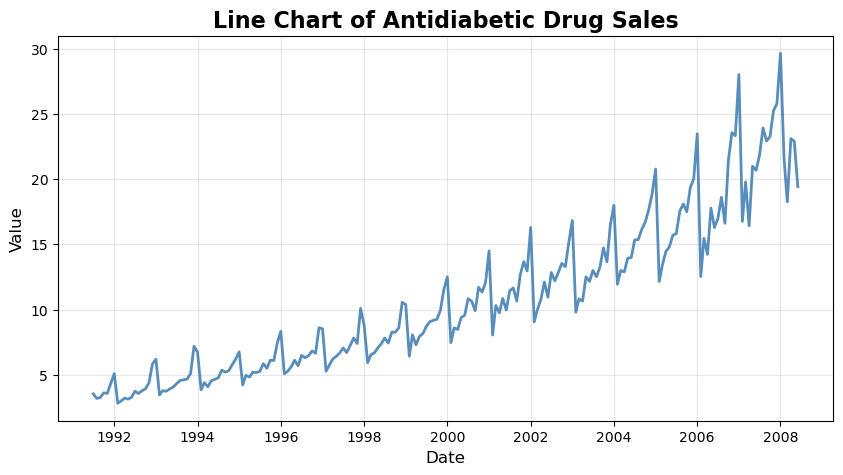

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df['Month'], df['Cost'], color='steelblue', linewidth=2.0, marker='', alpha=0.9)
plt.title("Line Chart of Antidiabetic Drug Sales", fontsize=16, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, alpha=0.3)

Below is a cell (hidden to avoid clutter) that shows the general form of the code for these plots.

In [4]:
# ==============================================================
#  GENERAL TEMPLATE: CONSTRUCTING A BASIC LINE CHART IN PYTHON
# ==============================================================
#
# GOAL:
# A line chart visualizes how a variable changes over a continuous axis
# (usually time). It’s the foundation of time-series visualization and
# trend analysis.
#
# --------------------------------------------------------------
# STEP 1 — PREPARE THE DATA
# --------------------------------------------------------------
# - Start with a DataFrame containing:
#     1. A time or numeric column for the X-axis (e.g. 'Date' or 'Time')
#     2. A numeric column for the Y-axis (e.g. 'Value')
# - Ensure the date/time column is parsed correctly:
#
# Example:
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date')  # chronological order
#
# --------------------------------------------------------------
# STEP 2 — CREATE THE PLOT
# --------------------------------------------------------------
# - Use Matplotlib or Seaborn to draw a simple line.
# - Label axes and title to make it clear.
#
# Example:
# plt.figure(figsize=(10,5))
# plt.plot(df['Date'], df['Value'],
#          color='steelblue', linewidth=2.0,
#          marker='', alpha=0.9)
#
# plt.title("Line Chart: Example Title", fontsize=16, weight='bold')
# plt.xlabel("Date", fontsize=12)
# plt.ylabel("Value", fontsize=12)
# plt.grid(True, alpha=0.3)
#
# --------------------------------------------------------------
# STEP 3 — OPTIONAL STYLING IMPROVEMENTS
# --------------------------------------------------------------
#  A. Highlight key points:
#     plt.scatter(df['Date'].iloc[-1], df['Value'].iloc[-1], color='red')
#
#  B. Add a moving average or trend line:
#     df['RollingMean'] = df['Value'].rolling(window=3).mean()
#     plt.plot(df['Date'], df['RollingMean'], color='orange', lw=2.5, label='3-month avg')
#
#  C. Use a seaborn style for modern visuals:
#     import seaborn as sns
#     sns.set_style("whitegrid")
#
#  D. Hide spines for a minimalist look:
#     for spine in plt.gca().spines.values():
#         spine.set_visible(False)
#
# --------------------------------------------------------------
# STEP 4 — ADD LEGEND / ANNOTATIONS
# --------------------------------------------------------------
# plt.legend(loc='best', frameon=False)
#
# Optional: annotate an important event or threshold
# plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', lw=1)
# plt.text(pd.Timestamp('2020-03-01'), df['Value'].max()*0.95,
#          'Event', color='red', ha='left', fontsize=9)
#
# --------------------------------------------------------------
# STEP 5 — SHOW OR SAVE THE PLOT
# --------------------------------------------------------------
# plt.tight_layout()
# plt.show()
#
# # Save to file if desired:
# # plt.savefig("line_chart.png", dpi=300, bbox_inches='tight')
#
# --------------------------------------------------------------
# NOTES:
# - Works with any numeric or datetime x-axis.
# - For multiple series, loop through columns or call plt.plot() multiple times.
# - Keep the data sorted by x-axis to ensure the line connects logically.
# - Combine with moving averages, regression lines, or markers for deeper insights.
# ==============================================================

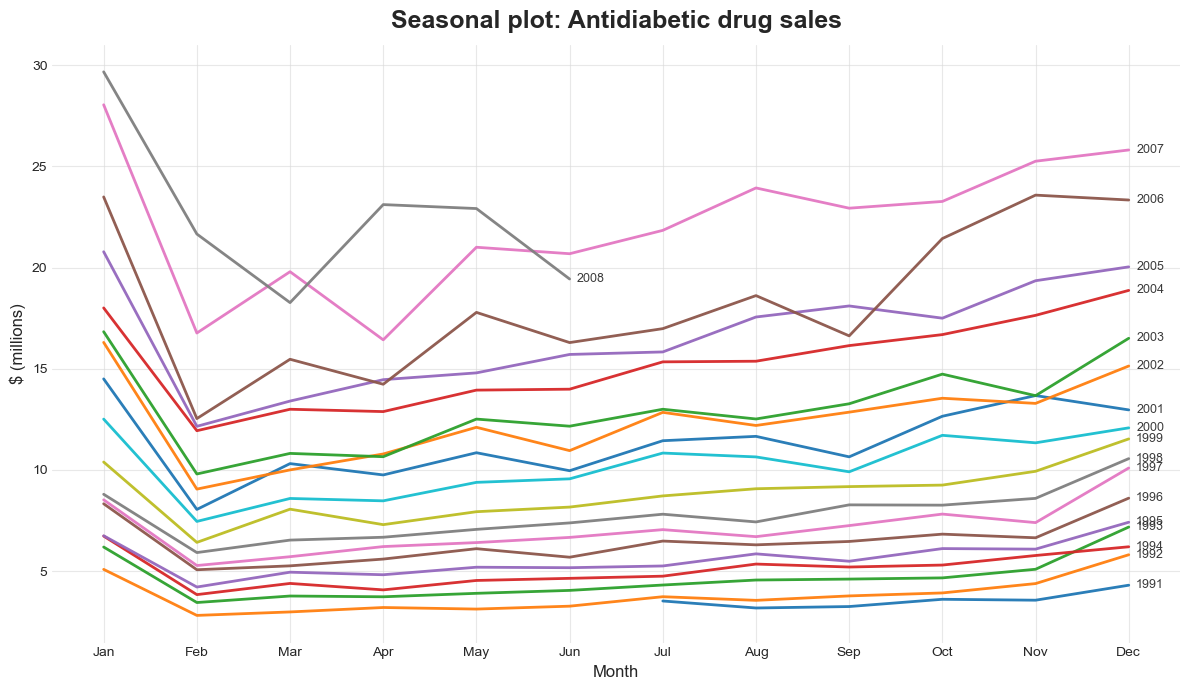

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure helpers derived from what you already have
# (Month is datetime64, Year is int, MonthName is 'Jan'..'Dec' categorical)
df = df.copy()
df['MonthNum'] = df['Month'].dt.month

# ---- fpp3-style seasonal plot ----
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12,7))

# draw older years first so newer sit on top (like gg_season)
for y, g in df.sort_values('Year').groupby('Year'):
    g = g.sort_values('MonthNum')
    ax.plot(g['MonthNum'], g['Cost'], lw=2, alpha=0.95)

# axes / labels
month_abbr = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_abbr)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('$ (millions)', fontsize=12)
ax.set_title('Seasonal plot: Antidiabetic drug sales', fontsize=18, weight='bold', pad=12)

# light grid, hide spines
ax.grid(True, color='#d9d9d9', alpha=0.6)
for spine in ax.spines.values():
    spine.set_visible(False)

# remove legend (too busy) and label years at the right (Dec), like the reference
ax.legend([], [], frameon=False)

for y, g in df.groupby('Year'):
    g = g.sort_values('MonthNum')
    last = g.iloc[-1]                      # December point for that year
    ax.text(last['MonthNum'] + 0.08, last['Cost'], str(y),
            va='center', fontsize=9, alpha=0.9)

plt.tight_layout()
plt.show()

### Interpretation

Above we can see the seasonal plot of the antidiabetic drug sales dataset. We can see right away that nearly every year there is a sharp dropoff in sales right at the beginning of January. This is due to some rules in Australia (the country this data is from) that make it advantageous for these drugs to be stockpiled before the end of the year. Since this pattern is consistent in it's interval and magnitude, we can assume that it is a seasonal pattern from the graph alone.

Below is a cell (hidden to avoid clutter) that shows the general form of the code for these plots.

In [6]:
# ==============================================================
#  GENERAL TEMPLATE: CONSTRUCTING A SEASONAL PLOT IN PYTHON
# ==============================================================
#
# A "seasonal plot" shows how a time series behaves within each
# seasonal cycle (e.g., months in each year, days in each week).
# Each cycle (usually a year) is drawn as one line over the
# season component (month/day/etc), to visualize recurring patterns.
#
# --------------------------------------------------------------
# STEP 1 — PREPARE THE DATA
# --------------------------------------------------------------
# - Start with a DataFrame containing a datetime column (e.g. 'Date')
#   and a numeric column (e.g. 'Value').
# - Extract the seasonal component (month, week, day, etc.)
#   and the grouping component (year, week number, etc.).
#
# Example:
# df['Year'] = df['Date'].dt.year
# df['Month'] = df['Date'].dt.month
# df['MonthName'] = df['Date'].dt.strftime('%b')
#
# define month order so it plots Jan to Dec
# month_order = ['Jan','Feb','Mar','Apr','May','Jun',
#                'Jul','Aug','Sep','Oct','Nov','Dec']
# df['MonthName'] = pd.Categorical(df['MonthName'],
#                                  categories=month_order,
#                                  ordered=True)
#
# --------------------------------------------------------------
# STEP 2 — BUILD THE PLOT
# --------------------------------------------------------------
# - Loop through each group (e.g. Year) and plot the Value over Month.
# - Use a color gradient or distinct colors to differentiate years.
# - Add labels, gridlines, and title for clarity.
#
# Example:
# plt.figure(figsize=(12,7))
# for y, g in df.groupby('Year'):
#     g = g.sort_values('Month')
#     plt.plot(g['Month'], g['Value'], lw=1.8, alpha=0.9)
#
# plt.title("Seasonal Plot: <your title here>", fontsize=16, weight='bold')
# plt.xlabel("Month")
# plt.ylabel("Value")
# plt.grid(True, alpha=0.4)
#
# --------------------------------------------------------------
# STEP 3 — SHOW OR SAVE THE PLOT
# --------------------------------------------------------------
# plt.tight_layout()
# plt.show()
#
# --------------------------------------------------------------
# ==============================================================

## Multiple seasonal periods

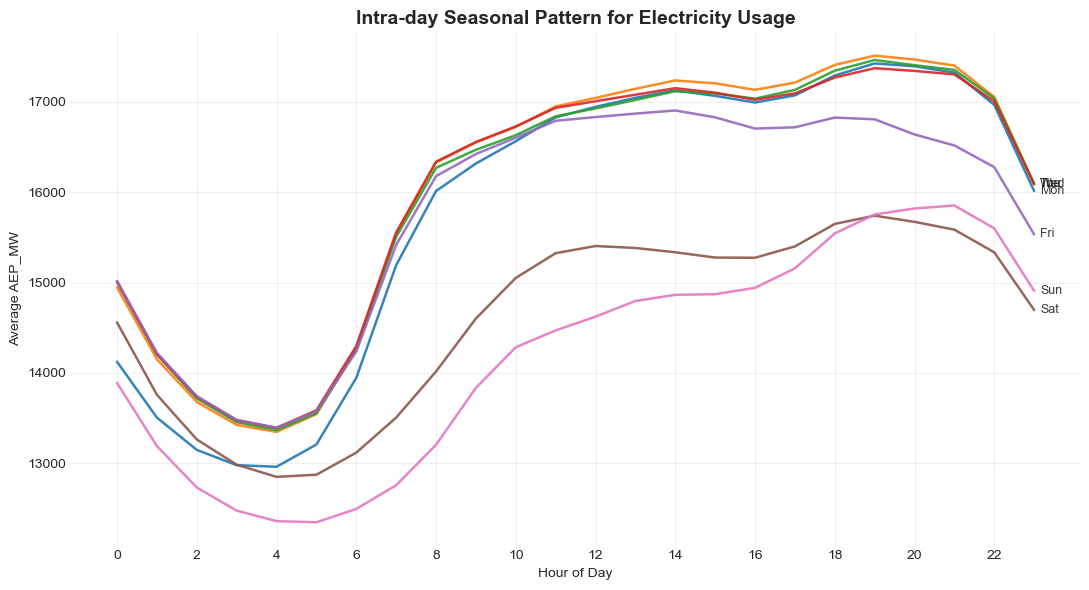

In [7]:
df2 = pd.read_csv(r"C:\Users\whoop\Downloads\AEP_hourly.csv")

df2['Datetime'] = pd.to_datetime(df2['Datetime'])
df2 = df2.sort_values('Datetime').set_index('Datetime')

df2['hour']        = df2.index.hour
df2['day_of_week'] = df2.index.dayofweek   # 0 = Monday, 6 = Sunday
df2['month']       = df2.index.month

dow_labels   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

intra_day = df2.groupby(['day_of_week', 'hour'], as_index=False)['AEP_MW'].mean()

plt.figure(figsize=(11,6))
for d, g in intra_day.groupby('day_of_week'):
    g = g.sort_values('hour')
    plt.plot(g['hour'], g['AEP_MW'], lw=1.8, alpha=0.9)

plt.title("Intra-day Seasonal Pattern for Electricity Usage", fontsize=14, weight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Average AEP_MW")
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)

for d, g in intra_day.groupby('day_of_week'):
    last = g[g['hour'] == 23]
    if not last.empty:
        plt.text(23.15, float(last['AEP_MW']), dow_labels[d],
                 va='center', fontsize=9, alpha=0.9)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

Above we can see that the given data (Electricity usage throughout the day) has a seasonality on the hourly level. We see a consistent sharp dropoff past midnight, then a sharp increase starting at 6am then plateauing at 9am.

In [8]:
# =============================================================================
#  UPDATED TEMPLATE: MULTIPLE-SEASONAL-PERIOD PLOTS (ROBUST VERSION)
# =============================================================================
#
# GOAL:
# Visualize multiple seasonal cycles in high-frequency data (e.g., hourly series
# with daily + weekly + annual seasonality). This template is hardened against
# common pitfalls we just saw.
#
# INPUT:
#   A DataFrame with a datetime column (e.g., 'timestamp') and a numeric column
#   (e.g., 'value').
#
# -----------------------------------------------------------------------------
# STEP 0 — IMPORTS
# -----------------------------------------------------------------------------
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
#
# -----------------------------------------------------------------------------
# STEP 1 — LOAD + ENSURE REAL DATETIMES (BEFORE set_index)
# -----------------------------------------------------------------------------
# df = pd.read_csv("your_file.csv")                           # 1) read
# df['timestamp'] = pd.to_datetime(df['timestamp'],           # 2) parse to dt
#                                  errors='coerce', utc=False)
# df = df.dropna(subset=['timestamp'])                        # 3) drop bad rows
# df = df.sort_values('timestamp')                            # 4) sort rows
# df = df.set_index('timestamp')                              # 5) make dt index
#
# # (Optional) De-duplicate and enforce monotonic index
# df = df[~df.index.duplicated(keep='first')].sort_index()
#
# -----------------------------------------------------------------------------
# STEP 2 — REGULARIZE FREQUENCY (if needed)
# -----------------------------------------------------------------------------
# If the data should be hourly but are irregular, resample to 'H'.
# Choose an aggregation that makes sense (mean/sum).
#
# desired_freq = 'H'
# if pd.infer_freq(df.index) != desired_freq:
#     df = df.resample(desired_freq).mean()
#
# # Handle missing after resample (choose ONE policy)
# # df = df.interpolate(limit_direction='both')    # smooth fill
# # df = df.fillna(method='ffill')                 # carry last value forward
# # df = df.dropna()                               # strict
#
# -----------------------------------------------------------------------------
# STEP 3 — RENAME VALUE COLUMN (optional) + TYPE SAFETY
# -----------------------------------------------------------------------------
# df = df.rename(columns={'your_value_col': 'value'})
# df['value'] = pd.to_numeric(df['value'], errors='coerce')
# df = df.dropna(subset=['value'])
#
# -----------------------------------------------------------------------------
# STEP 4 — CALENDAR FEATURES (NOW SAFE: DatetimeIndex confirmed)
# -----------------------------------------------------------------------------
# df['year']        = df.index.year
# df['month']       = df.index.month
# df['day_of_week'] = df.index.dayofweek     # 0 = Mon, 6 = Sun
# df['hour']        = df.index.hour
#
# dow_labels   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
# month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
#
# -----------------------------------------------------------------------------
# STEP 5 — AGGREGATIONS FOR EACH SEASONAL VIEW
# -----------------------------------------------------------------------------
# # A) Daily cycle (hour-of-day), lines by day-of-week
# intra_day = (df
#              .groupby(['day_of_week','hour'], as_index=False)['value']
#              .mean())
#
# # B) Weekly cycle (Mon..Sun), lines by month
# intra_week = (df
#               .groupby(['month','day_of_week'], as_index=False)['value']
#               .mean())
#
# # C) Annual cycle (Jan..Dec), lines by year
# intra_year = (df
#               .groupby(['year','month'], as_index=False)['value']
#               .mean())
#
# -----------------------------------------------------------------------------
# STEP 6 — PLOTTING HELPERS (clean look, no heavy legends)
# -----------------------------------------------------------------------------
# def season_plot(ax, data, x, group, y, x_ticks=None, x_ticklabels=None,
#                 title="", ylabel=""):
#     # draw each group as a line
#     for k, g in data.groupby(group):
#         g = g.sort_values(x)
#         ax.plot(g[x], g[y], lw=1.8, alpha=0.9)
#     if x_ticks is not None:
#         ax.set_xticks(x_ticks)
#     if x_ticklabels is not None:
#         ax.set_xticklabels(x_ticklabels)
#     ax.set_title(title, fontsize=14, weight='bold')
#     ax.set_ylabel(ylabel)
#     ax.grid(True, alpha=0.35)
#     for s in ax.spines.values():
#         s.set_visible(False)
#
# def label_at_right(ax, data, x, group, y, label_func):
#     # place text at the last x for each group
#     last_x = data[x].max()
#     for k, g in data.groupby(group):
#         gg = g[g[x] == last_x]
#         if not gg.empty:
#             ax.text(last_x + 0.15, float(gg[y]), label_func(k),
#                     va='center', fontsize=9, alpha=0.9)
#
# -----------------------------------------------------------------------------
# STEP 7 — BUILD THE THREE SEASONAL PLOTS
# -----------------------------------------------------------------------------
# # A) Intra-day: x = hour (0..23), lines by day-of-week
# fig, ax = plt.subplots(figsize=(11,5))
# season_plot(ax, intra_day,
#             x='hour', group='day_of_week', y='value',
#             x_ticks=list(range(0,24,2)), x_ticklabels=[str(h) for h in range(0,24,2)],
#             title='Intra-day seasonal pattern (lines by day-of-week)',
#             ylabel='Average value')
# label_at_right(ax, intra_day, x='hour', group='day_of_week', y='value',
#                label_func=lambda d: ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d])
# plt.tight_layout(); plt.show()
#
# # B) Intra-week: x = day-of-week (0..6), lines by month
# fig, ax = plt.subplots(figsize=(11,5))
# season_plot(ax, intra_week,
#             x='day_of_week', group='month', y='value',
#             x_ticks=range(7), x_ticklabels=dow_labels,
#             title='Intra-week seasonal pattern (lines by month)',
#             ylabel='Average value')
# label_at_right(ax, intra_week, x='day_of_week', group='month', y='value',
#                label_func=lambda m: month_labels[m-1])
# plt.tight_layout(); plt.show()
#
# # C) Intra-year: x = month (1..12), lines by year
# fig, ax = plt.subplots(figsize=(11,5))
# season_plot(ax, intra_year,
#             x='month', group='year', y='value',
#             x_ticks=range(1,13), x_ticklabels=month_labels,
#             title='Intra-year seasonal pattern (lines by year)',
#             ylabel='Average value')
# label_at_right(ax, intra_year, x='month', group='year', y='value',
#                label_func=lambda yr: str(yr))
# plt.tight_layout(); plt.show()
#
# -----------------------------------------------------------------------------
# COMMON PITFALLS (and how this template avoids them)
# -----------------------------------------------------------------------------
# • KeyError / AttributeError on .index.hour:
#     -> We explicitly convert to datetime BEFORE set_index.
# • Spiky / irregular lines:
#     -> We sort, de-duplicate, and (optionally) resample to a regular freq.
# • NaNs after resample:
#     -> Pick a fill policy (interpolate/ffill/drop) explicitly.
# • Overcrowded legends:
#     -> We label lines at the right; hide big legends.
# • Silent dtype issues:
#     -> We coerce 'value' to numeric and drop bad rows.
# =============================================================================

In [9]:
df_beer = pd.read_csv(r"C:\Users\whoop\Downloads\Quarterly_Australian_Beer_production_748_83.csv")
df_beer = df_beer.drop(columns=[c for c in ['Unnamed: 0', 'X'] if c in df_beer.columns])
df_beer.rename(columns={'value':'beer_production'}, inplace=True)
df_beer['time'] = pd.to_numeric(df_beer['time'], errors='coerce')
df_beer['beer_production'] = pd.to_numeric(df_beer['beer_production'], errors='coerce')
year = np.floor(df_beer['time']).astype(int)
frac = df_beer['time'] - year
month = np.round(frac * 12).astype(int) + 1
month = month.clip(1, 12)
df_beer['Month'] = pd.to_datetime(dict(year=year, month=month, day=1))
df_beer = df_beer.set_index('Month')
df_beer.index.name = 'Date'
df_beer.drop(axis=1, columns='time', inplace=True)
df_beer = df_beer.loc['1975-01-01':'1985-01-01']
display(df_beer.tail())

,beer_production
Date,
1984-01-01,453
1984-04-01,430
1984-07-01,417
1984-10-01,552
1985-01-01,464


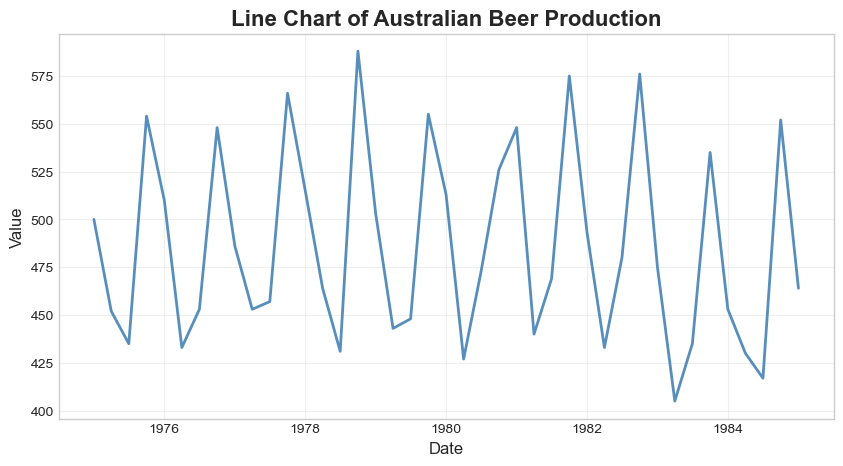

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df_beer.index, df_beer['beer_production'], color='steelblue', linewidth=2.0, marker='', alpha=0.9)
plt.title("Line Chart of Australian Beer Production", fontsize=16, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, alpha=0.3)

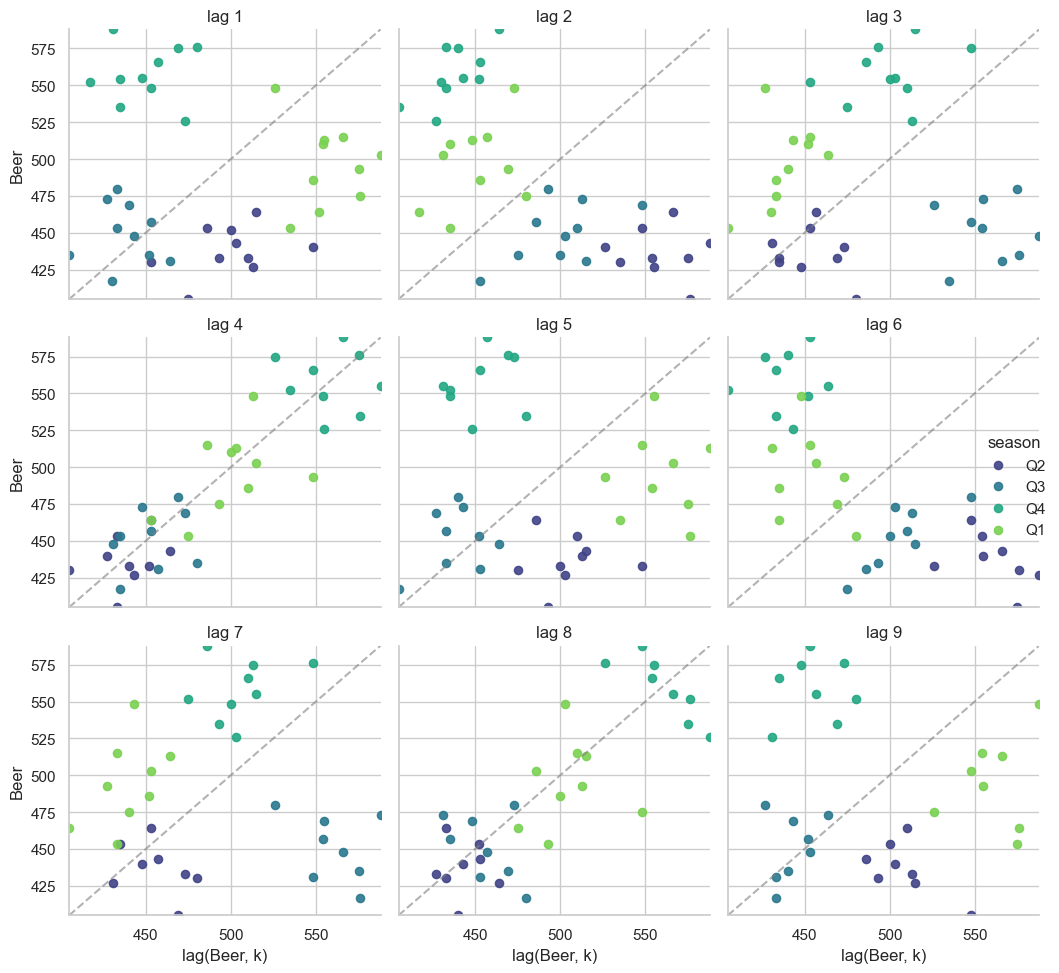

In [11]:
df_quarterly = df_beer['beer_production'].resample('QE').mean()
df_quarterly = df_quarterly.to_frame(name='Beer')

# Add season labels
df_quarterly['season_num'] = df_quarterly.index.quarter
season_labels = {1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'}
df_quarterly['season'] = df_quarterly['season_num'].map(season_labels)

# Build long-format lag DataFrame for lags 1–9
lags = range(1, 10)
pieces = []

for k in lags:
    tmp = df_quarterly[['Beer', 'season']].copy()
    tmp['Beer_lag'] = tmp['Beer'].shift(k)
    tmp['lag'] = k
    tmp = tmp.dropna()
    pieces.append(tmp)

lag_df = pd.concat(pieces)

# Faceted lag plot
sns.set(style="whitegrid")

g = sns.FacetGrid(
    lag_df,
    col="lag",
    col_wrap=3,
    hue="season",
    height=3.3,
    aspect=1.0,
    palette="viridis"
)

g.map_dataframe(plt.scatter, "Beer_lag", "Beer", s=35, alpha=0.9)

# Add dashed 45 degree line to each facet
x_min, x_max = lag_df['Beer_lag'].min(), lag_df['Beer_lag'].max()
y_min, y_max = lag_df['Beer'].min(), lag_df['Beer'].max()
low, high = min(x_min, y_min), max(x_max, y_max)

for ax in g.axes.flatten():
    ax.plot([low, high], [low, high], '--', color='gray', alpha=0.6)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)

g.set_axis_labels("lag(Beer, k)", "Beer")
g.set_titles("lag {col_name}")
g.add_legend(title="season")

plt.tight_layout()
plt.show()

### Interpretation:

Above we can see a plot of the lagged values of beer production versus the current value. In this data we are examining the beer production by quarter, which is every quarter of a year of course. Quarter 1 is seen in light green, Q2 in dark blue, Q3 in light blue, and Q4 in turqoise. It is important to note that the "lag 4", or value 4 qaurters ago is just the value from the year before. Observing the relationship between the lagged vs actual for each quarter in each plot we see the following:
#### Lag 1
- For Q1, the lagged values (last years Q4) are typically high and the current are usually middling
- For Q2, the lagged values (Q1) are typically middling and the current are usually low
- For Q3, the lagged values (Q2) are typically low and the current values are usually low
- For Q4, the lagged values (Q3) are typically are usually low and the current values are high
#### Lag 2
- For Q1, the lagged values (last years Q3) are typically low and the current are usually middling
- For Q2, the lagged values (last years Q4) are typically high and the current are usually low
- For Q3, the lagged values (Q1) are typically middle and the current values are usually low
- For Q4, the lagged values (Q2) are typically are usually low and the current values are high
#### Lag 3
- For Q1, the lagged values (last years Q2) are typically low and the current are usually middling
- For Q2, the lagged values (last years Q3) are typically low and the current are usually low
- For Q3, the lagged values (last years Q4) are typically high and the current values are usually low
- For Q4, the lagged values (Q1) are typically are usually middling and the current values are high
#### Lag 4
- For Q1, the lagged values (last years Q1) are typically middling and the current are usually middling
- For Q2, the lagged values (last years Q2) are typically low and the current are usually low
- For Q3, the lagged values (last years Q3) are typically low and the current values are usually low
- For Q4, the lagged values (last years Q4) are typically are usually high and the current values are high
#### Processing this information:
When making these observations it is important to reference the original line chart of the time series. While the Lag 1, 2, and 3 plots show some wildly inconsistent results, the fourth lag shows very strong correlation between the lagged and actual for each quarter. This can be confirmed by looking at the line chart, the data fluctuates consistently in both magnitude and frequency, and that frequency is 1 year. Since the data is consistent in this manner, any lag plot beyond 4 will show the same patterns as their counterpart 4 lags back (the 8th lag plot, showing the relation between the value 2 years back and the current, will show the same relation as the 4th lag plot). In practice we can use the general rule of thumb that lag plots where all observations cluster around the 45 degree line show the strength of the lag in predictions.

## Decomposition

In order to fully understand the underlying structure that drives the movements in a time series, we analyze its key components: **trend**, **seasonality**, and **residuals**. The clarity of these components depends heavily on how the **variance** behaves over time.
Real-world time series can exhibit:
- **Stable variance** (constant amplitude)  
- **Mildly increasing variance**  
- **Strongly increasing variance**  
- **Variance increasing proportionally with the level** (multiplicative behavior)

When the variance increases with the level of the series, the seasonal and trend patterns also tend to expand or contract proportionally. In such cases, the series behaves **multiplicatively**, and this often makes it harder for decomposition and ARIMA-based models to correctly identify structure.
To address this, we apply a **variance-stabilizing transformation** such as a log transform or a Box-Cox transform before performing diagnostics like **ACF/PACF** or fitting models. This transforms multiplicative relationships into additive ones, which greatly improves the performance of **STL**, **ETS**, **SARIMA**, and many statistical models.
It is important to note that not all data can be transformed in these ways; Box-Cox and log transform methods require **exclusively positive values**. In cases where a variance-stabilizing transformation is not needed, we typically apply a **first difference transformation** to achieve stationarity if stationarity is still not met.
When we use a maximum likelihood estimator to obtain the optimal lambda for the Box-Cox transformation, if that lambda is one (or close to one), then the transformation is not needed because the model is likely **additive**.
In the dataset below, the variance clearly increases as the level of the series increases. Therefore, we use a **multiplicative (or transformed-to-additive) decomposition**, because this aligns with the structure of the data and stabilizes the amplitude of the seasonal and residual components.

In [12]:
data = pd.read_csv(r"C:\Users\whoop\Downloads\AirPassengers.csv", index_col=0)
data.index = pd.to_datetime(data.index)
ACF_ex1 = data

# Plot the data
fig = px.line(data, x=data.index, y='#Passengers',
              labels=({'#Passengers': 'Passengers', 'Month': 'Date'}))

fig.update_layout(template="simple_white", font=dict(size=18),
                  title_text='Airline Passengers', width=650, title_x=0.5, height=400)

fig.show()

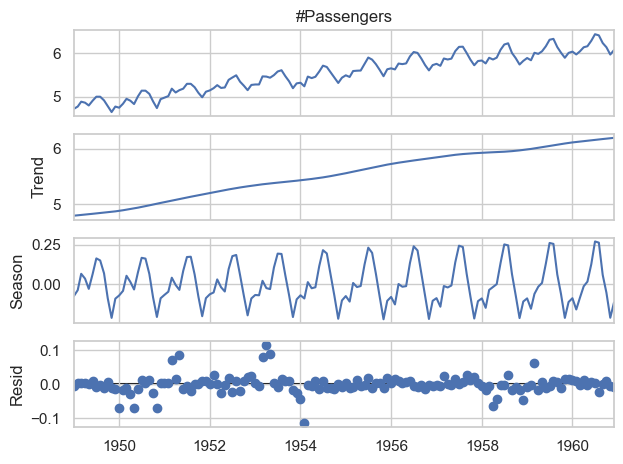

In [16]:
s = data['#Passengers'].asfreq('MS').dropna()

# Log transform so multiplicative structure becomes additive for STL
s_log = np.log(s)

# STL decomposition
stl = STL(s_log, period=12, robust=True)
res = stl.fit()

# Plot STL components
res.plot()
plt.tight_layout()
plt.show()

### Interpretation of decomposition
- The data trends upwards
- there is a strong seasonal component that shows a peak in the middle of the year
These components along with the residuals make up the series itself and help us determine what parameters and even models we should consider

### More Cases 

The next case is one with an additive effect, but we run the code for the box-cox transformation anyway to examine the results and see whether or not the series has a multiplicative effect present.

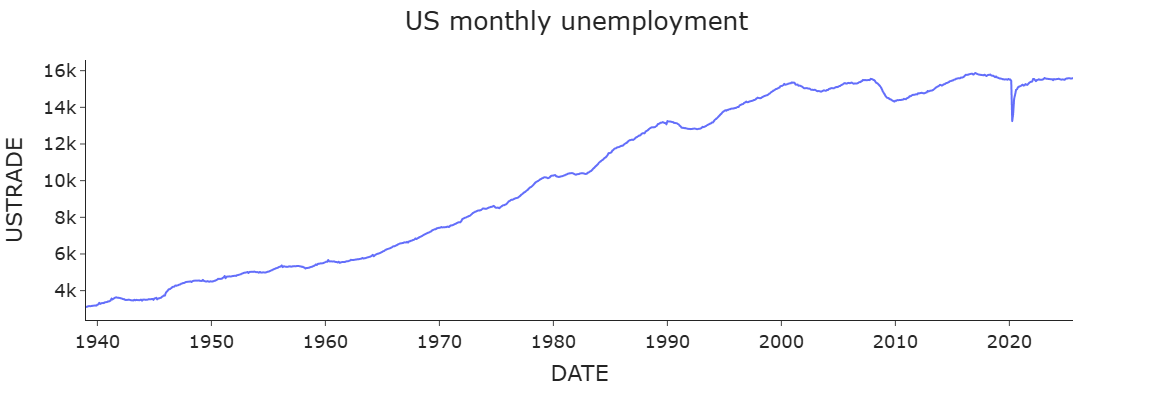

In [23]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=USTRADE"
us = pd.read_csv(url)
us['DATE'] = pd.to_datetime(us['observation_date'])
us = us.set_index('DATE')

# Plot the data
fig = px.line(us, x=us.index, y='USTRADE',
              labels=({'#US monthly unemployment': 'USTRADE', 'Month': 'DATE'}))

fig.update_layout(template="simple_white", font=dict(size=18),
                  title_text='US monthly unemployment', width=650, title_x=0.5, height=400)

fig.show()

Lambda: 0.7979139945439018


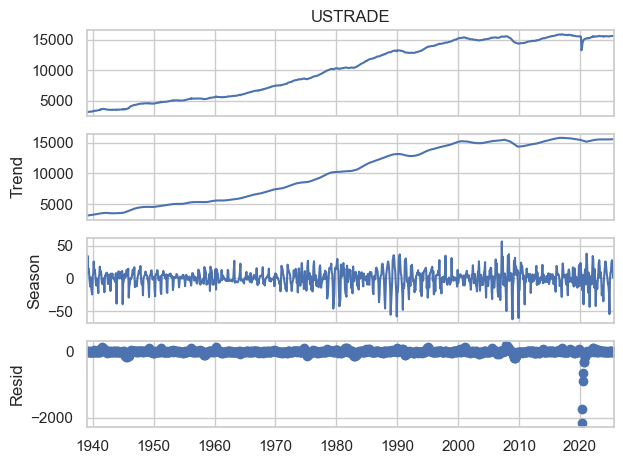

In [24]:
s = us['USTRADE'].asfreq('MS')
s = s.dropna()
s = s[s > 0]

ACF_ex2 = s

# Box-Cox lambda check
_, lam = boxcox(s.dropna())
print("Lambda:", lam)

# Since lambda ~ 1 we use additive STL on the original series
stl = STL(s, period=12, robust=True)
res = stl.fit()

res.plot()
plt.show()

## Understanding Box-Cox

For this next case we will use box-cox on a synthetic dataset and consider what approach should be taken when we see different values of the lambda parameter in the box-cox transformation.

The Box–Cox transformation is defined as:

$$
y^{(\lambda)} =
\begin{cases}
\dfrac{y^\lambda - 1}{\lambda}, & \lambda \neq 0, \\[8pt]
\ln(y), & \lambda = 0.
\end{cases}
$$


Below is a summary of the lambda values, their meanings, and what action should be taken before decomposing and modeling.

| Lambda Range       | Interpretation of Data                              | Seasonality Structure            | Recommended Models & Box–Cox Guidance                                      |
|--------------------|------------------------------------------------------|----------------------------------|----------------------------------------------------------------------------|
| **λ ≈ 1**          | Variance is stable; transformation unnecessary       | Additive                         | **No Box–Cox needed.** Use ETS(A,A,N), ETS(A,A,A), ARIMA on raw data, STL + ARIMA |
| **0.8 ≤ λ < 1**    | Very mild variance growth; transformation optional   | Mostly additive                  | Box–Cox is **not required**; safe to use raw data. Additive ETS, STL + ARIMA, SARIMA (raw or lightly BC’ed) |
| **0.3 ≤ λ < 0.8**  | Moderate multiplicative behavior                    | Amplitude grows with level       | **Apply Box–Cox.** Use Box–Cox(λ) + Additive STL, ETS(A,Ad,A), SARIMA on BC data |
| **0.0 ≤ λ < 0.3**  | Strong multiplicative effects                       | Strong amplitude scaling         | **Use log or strong Box–Cox.** Log(y) or Box–Cox(λ) + Additive STL, ARIMA/SARIMA on transformed data |
| **λ = 0**          | Pure multiplicative structure (log case)            | Fully multiplicative             | **This *is* the log transform.** Log(y) + Additive STL, ETS(M,*,*), TBATS/BATS |
| **λ < 0**          | Extreme multiplicative / heavy-tailed behavior      | Highly unstable / erratic        | **Box–Cox may be inappropriate** (requires positive data). Consider robust transforms, STL + robust ARIMA, TBATS |


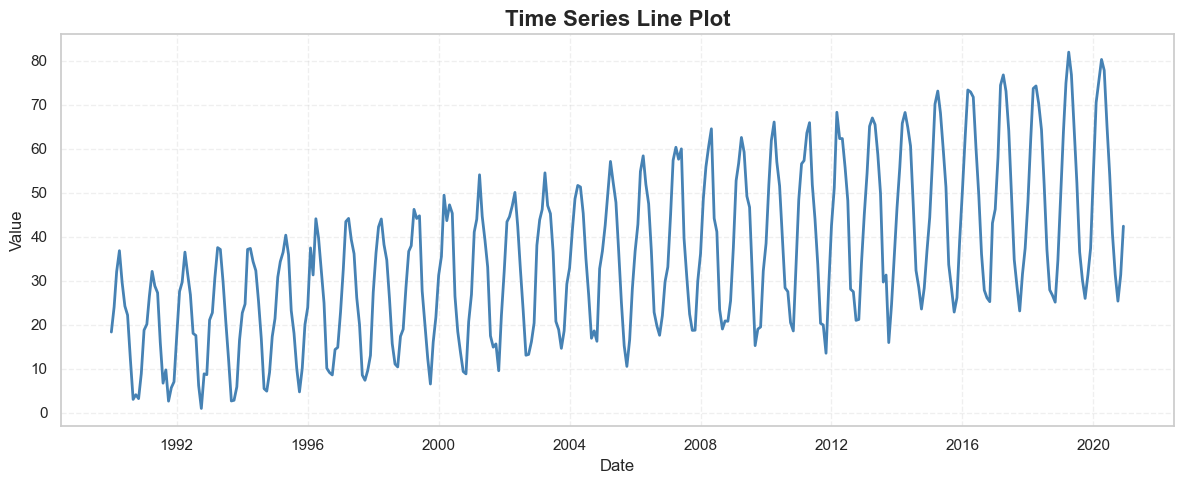

In [19]:
ts = pd.read_csv(r"C:\Users\whoop\moderate_lambda_series_synthetic.csv", parse_dates=[0], index_col=0)
ts = ts.squeeze()
s = ts.dropna()
s = s[s > 0]

ACF_ex3 = s

plt.figure(figsize=(12, 5))

plt.plot(s.index, s.values, linewidth=2.0, color='steelblue')

plt.title("Time Series Line Plot", fontsize=16, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)

plt.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


Estimated Box–Cox λ: 0.618

Interpretation:
0.3 ≤ λ < 0.8 → **moderate multiplicative effect**.
 - Seasonal swings grow with the level, but not wildly.
 - Box–Cox(λ) is a good idea; use additive STL on the transformed series.


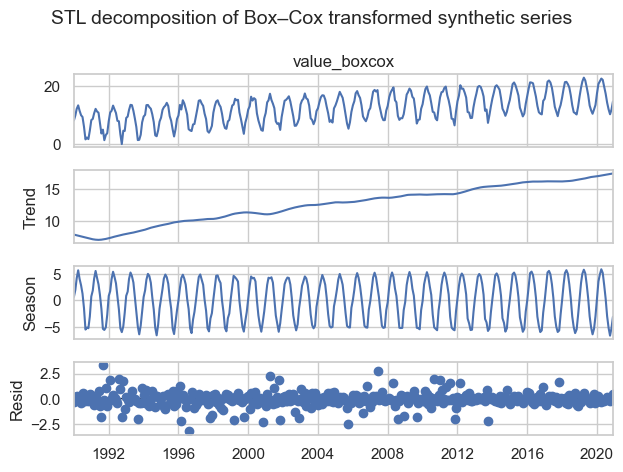

In [20]:
# Estimate Box-Cox λ

y_bc, lam = boxcox(s.values)
print(f"\nEstimated Box–Cox λ: {lam:.3f}")

print("\nInterpretation:")
if lam >= 0.8:
    print("λ ≈ 1 → mostly additive; raw STL would be fine.")
elif lam >= 0.3:
    print("0.3 ≤ λ < 0.8 → **moderate multiplicative effect**.\n"
          " - Seasonal swings grow with the level, but not wildly.\n"
          " - Box–Cox(λ) is a good idea; use additive STL on the transformed series.")
elif lam >= 0:
    print("0 ≤ λ < 0.3 → strong multiplicative effect; log-like transform is important.")
else:
    print("λ < 0 → very strong multiplicative / heavy tails; strong transform needed.")

# STL on Box-Cox transformed series
s_bc = pd.Series(y_bc, index=s.index, name="value_boxcox")

stl = STL(s_bc, period=12, robust=True)
res = stl.fit()

fig = res.plot()
fig.suptitle("STL decomposition of Box–Cox transformed synthetic series", fontsize=14)
plt.tight_layout()
plt.show()

## Wrap up on Decomposition

Decomposition is one of our first diagnostic steps and is useful in determining what approach we will use going forward. It reveals the **seasonality**, **trend**, and **noise** in the series. The **residual component** is essential in identifying structural break points where the data's underlying process is disrupted. 

For example, in the US monthly employment case, we observe extreme residuals in **2008** and **2020**, with relatively little noise elsewhere. What does that tell us? Recessions break the pattern of employment in the United States.
This makes the decomposition step essential, because it not only clarifies the underlying components but also prepares us for the modeling stage. As mentioned before, forecasting models do not perform well when structural breaks disrupt the process (unless those factors behind the breaks are facotred in). This issue is often resolved by **transforming the dataset**, **fitting the model**, and then **applying the inverse transformation** to the model's results.

Other modeling issues can be addressed through **parameter tuning**, which we will cover in the following section.

## Plotting and Interpretting ACF and PACFs

When creating our candidate model, we'll need something to base our parameters on. While the decomposition step gives us a window into the trend, seasonality, and breaks, it does not give us much when it comes to the parameters that control the Auto-Regressive and Moving-Average parts of our (S)ARIMA(X) framework (reminder that the entire acronym stands for Seasonal Auto-Regressive Integrated Moving Average with eXogenous variables). Below we will go over some examples that show the results of PACF and ACF plots and how to interpret them.

### First Case: Airline Passengers Data 

This will serve as our first example of what ACF and PACF plots will look like when the data is not differenced correctly. When there are issues with stationarity, it is often the case that the ACF and PACF results will be essentially useless. When seasonality and trends are not removed we cannot see what lags will be significant nor which lags of which parameters. 

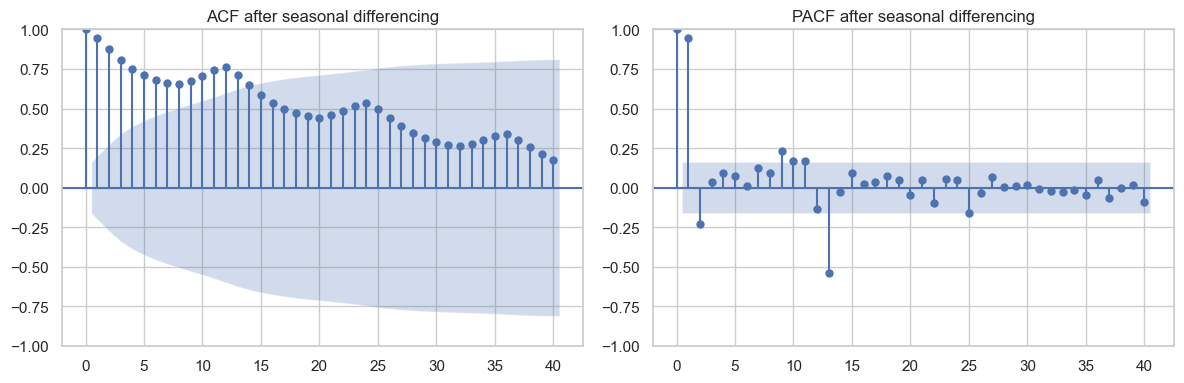

In [88]:
# Start from the raw series
y = ACF_ex1.dropna()

# ACF + PACF in a 1x2 layout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y, lags=40, ax=axes[0])
axes[0].set_title("ACF after seasonal differencing")

plot_pacf(y, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF after seasonal differencing")

plt.tight_layout()
plt.show()

#### Initial Interpretation

We can see above that there are some strange things going on in the ACF plot of the unchanged series. The lags fluctuate at around .75, which is unusually high for this many lags. The shaded region, which represents the level of correlation that we can dismiss as insignificant due to it being possible due to random chance, is also quite wide. This sets off the red flag that our series may not be stationary yet, and we can test this formally to get a definite answer. Below we use the Augmented Dickey-Fuller test to examine whether or not our series is stationary when we apply no changes, apply a seasonal difference, apply a first difference.

In [42]:
y = ACF_ex1.dropna()

#setting seasonal pattern ascertained from STL decomp
s = 12  

# Augmented Dickey Fuller on original series
result_orig = adfuller(y)
print("Original series:")
print("  ADF stat:", result_orig[0])
print("  p-value :", result_orig[1], "\n")

# ADF on seasonally differenced series
y_seas = y.diff(s).dropna()
result_seas = adfuller(y_seas)
print("Seasonally differenced (D=1):")
print("  ADF stat:", result_seas[0])
print("  p-value :", result_seas[1], "\n")

# ADF on seasonally + first differenced series
y_seas_diff = y_seas.diff().dropna()
result_seas_diff = adfuller(y_seas_diff)
print("Seasonal + first differenced (D=1, d=1):")
print("  ADF stat:", result_seas_diff[0])
print("  p-value :", result_seas_diff[1])

Original series:
  ADF stat: 0.8153688792060597
  p-value : 0.9918802434376411 

Seasonally differenced (D=1):
  ADF stat: -3.3830207264924805
  p-value : 0.011551493085514982 

Seasonal + first differenced (D=1, d=1):
  ADF stat: -15.595618083746338
  p-value : 1.856511600123444e-28


These results may be ambiguous to the uninitiated so here is a brief explanation: When we run the ADF test we get a test statistic and a p-value, two measures that are involved in hypothesis testing. The null hypothesis in this situation is that the series is not stationary, and the alternative is that the series is stationary. Typically we will use an alpha of 0.05 for the test, so we will reject the null and accept the alternative hypothesis if the p-value is below 0.05. Essentially what we are doing is generating a test statistic and a p-value that represent the probability that we would see this ADF result given the series is non-stationary. In practice however, we can dismiss all of this and simply run the ADF, and conclude that the series is stationary if the p-value is below 0.05.  

The original series has a p-value of .99 when using the ADF test, which confirms it is not stationary. The seasonally differenced series has a p-value of .01, which is of course under 0.05; since this shows sufficient evidence that the series is now stationary we stop at seasonally differencing. Once we see the ADF suggests stationarity we can use the version that has that result, anything past that is overkill and will obscure the significance of the ACF and PACF plots

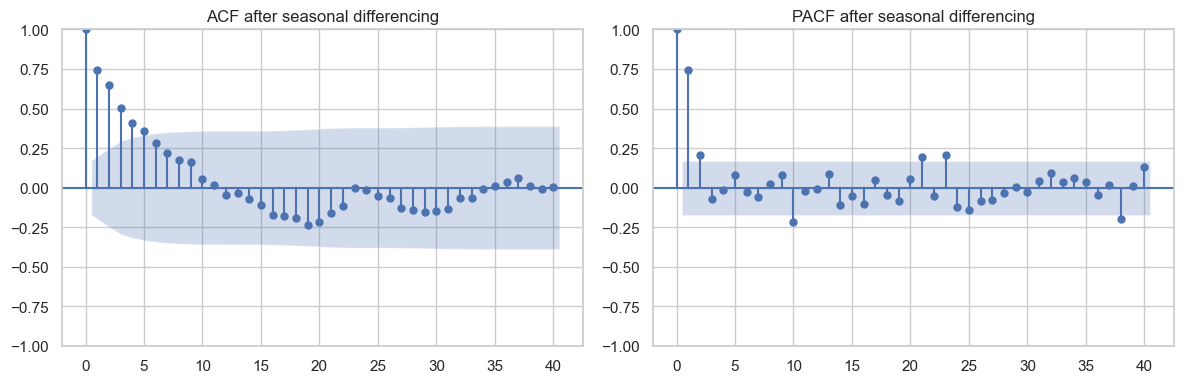

In [89]:
# Start from the raw series
y = ACF_ex1.dropna()

seasonal_lag = 12

# seasonal difference
y_seasonal_diff = y.diff(seasonal_lag).dropna()

# ACF + PACF in a 1x2 layout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y_seasonal_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF after seasonal differencing")

plot_pacf(y_seasonal_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF after seasonal differencing")

plt.tight_layout()
plt.show()

#### Interpreting the finished plots

To interpret these plots we examine which lags lie beyond the shaded region. These are called signigicant lags. The ACF plots determine the Moving-Average component of our model (MA(q)): If the ACF cuts off quickly after a few consecutive significant lags then a MA process is present and we use the last significant lag as q. The PACF plot determines the Auto-Regressive component of our model (AR(p)): If PACF cuts off quickly after a few consecutive significant lags then a AR process is present and we use the last significant lag as p. If both decay then oscillate at 0 then an ARMA/ARIMA process is present, and both processes are present. In the case of an ARMA/ARIMA process, the parameters need to be tuned by making candidate models and picking the one that performs best. 

| | AR($p$) | MA($q$) | ARMA($p$, $q$) |
|-|-|-|-|
|ACF|Tails off (Geometric decay) | Significant at lag $q$ / Cuts off after lag $q$|Tails off (Geometric decay) |
|PACF| Significant at each lag $p$ / Cuts off after lag $p$|Tails off (Geometric decay) |Tails off (Geometric decay) |

Applying this knowledge to the first example, we can see that the PACF shows 2 consecutive significant lags then a sharp cutoff. This combined with the decaying ACF plot tells us there is an Auto-Regressive process and an AR(p=2) model would do well as long as we factor in the seasonality at 12 months. 

### Second Case: US Employment Data

Below we see an example of the ACF plots indicating our series is not quite stationary yet in a unique way. This example is what we call a unit root/random walk, and it makes the ACFs and PACFs essentially useless. This is seen in cases where there is a strong trend, cumulative processes, processes with permanent shocks, and in cases where we have simply not differenced adequately yet. Put simply, a unit root/random walk means each new value is essentially just the last one with some added noise, the level drifts, and the variance grows without bound. When our ACF stays near 1 forever we know there is a unit root. We solve this by elimating stationarity issues, whether they be seasonality or a significant trend.

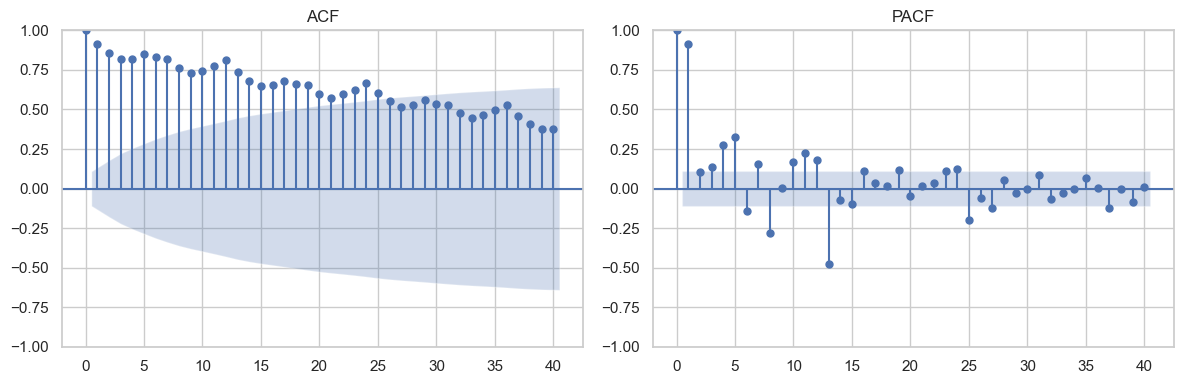

In [87]:
# Start from the raw series
y = ACF_ex2.dropna()

# ACF + PACF in a 1x2 layout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y, lags=40, ax=axes[0])
axes[0].set_title("ACF")

plot_pacf(y, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()

In [44]:
y = ACF_ex2.dropna()

# setting seasonal period
s = 12

# ADF on original 
result_orig = adfuller(y)
print("Original series:")
print("  ADF stat:", result_orig[0])
print("  p-value :", result_orig[1], "\n")

# ADF on seasonally differenced
y_seas = y.diff(s).dropna()
result_seas = adfuller(y_seas)
print("Seasonally differenced (D=1):")
print("  ADF stat:", result_seas[0])
print("  p-value :", result_seas[1], "\n")

# ADF on seasonally + first differenced
y_seas_diff = y_seas.diff().dropna()
result_seas_diff = adfuller(y_seas_diff)
print("Seasonal + first differenced (D=1, d=1):")
print("  ADF stat:", result_seas_diff[0])
print("  p-value :", result_seas_diff[1])

Original series:
  ADF stat: -1.3671176350176453
  p-value : 0.5979349201106978 

Seasonally differenced (D=1):
  ADF stat: -6.266146127998731
  p-value : 4.109508613695597e-08 

Seasonal + first differenced (D=1, d=1):
  ADF stat: -12.688157354317893
  p-value : 1.1475456627294835e-23


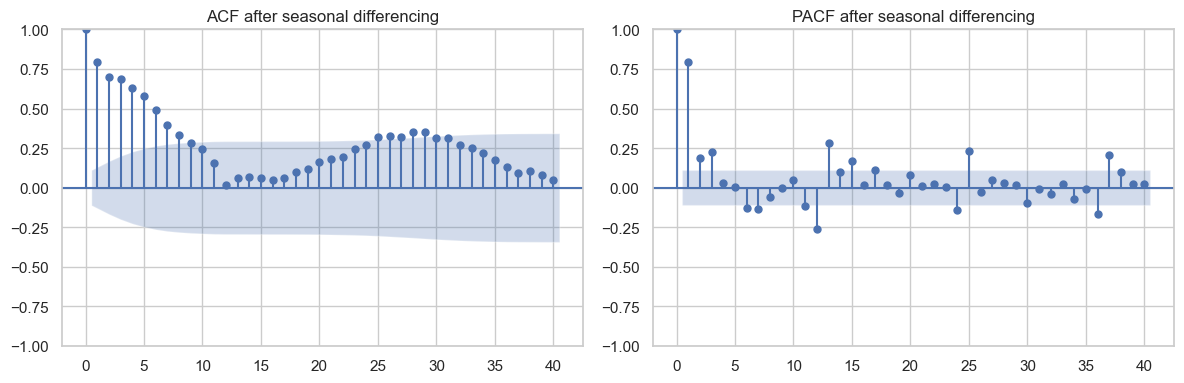

In [86]:
# Start from the raw series
y = ACF_ex2.dropna()

seasonal_lag = 12

# seasonal difference
y_seasonal_diff = y.diff(seasonal_lag).dropna()

# ACF + PACF in a 1x2 layout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y_seasonal_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF after seasonal differencing")

plot_pacf(y_seasonal_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF after seasonal differencing")

plt.tight_layout()
plt.show()

#### Interpreting the finished plots

After finishing the plots we see a sharp cutoff in the PACF indicating an AR process, specifically AR(1) after seasonal differencing. 

### Third Case: Catfish Production Data

In [129]:
s = (
    pd.read_csv(r"C:\Users\whoop\Downloads\catfish.csv",
                parse_dates=[0], index_col=0, date_format="%Y-%m-%d")
      .squeeze("columns")            # 1-col DataFrame -> Series
      .sort_index()
)

# Give the index a regular frequency (if inferable)
s = s.asfreq(s.index.inferred_freq)

Lambda: 1.1657857140361068


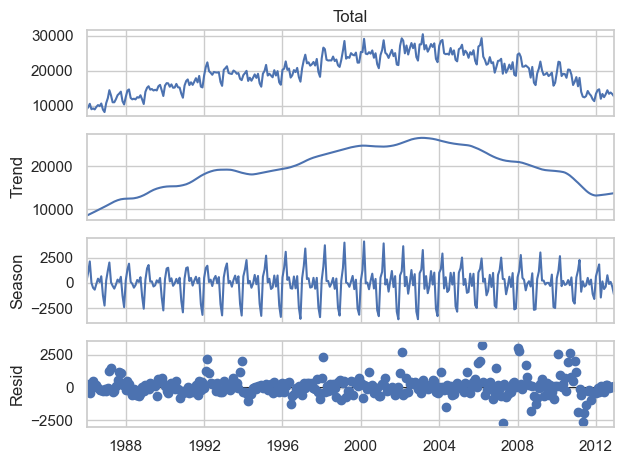

In [130]:
s = s.dropna()
s = s[s > 0]

# Box-Cox lambda check
_, lam = boxcox(s.dropna())
print("Lambda:", lam)

# Since lambda ~ 1 we use additive STL on the original series
stl = STL(s, period=12, robust=True)
res = stl.fit()

res.plot()
plt.show()

In [131]:
y = s.dropna()

# setting seasonal period
seasonal_period = 12

# ADF on original 
result_orig = adfuller(y)
print("Original series:")
print("  ADF stat:", result_orig[0])
print("  p-value :", result_orig[1], "\n")

# ADF on seasonally differenced
y_seas = y.diff(seasonal_period).dropna()
result_seas = adfuller(y_seas)
print("Seasonally differenced (D=1):")
print("  ADF stat:", result_seas[0])
print("  p-value :", result_seas[1], "\n")

# ADF on seasonally + first differenced
y_seas_diff = y_seas.diff().dropna()
result_seas_diff = adfuller(y_seas_diff)
print("Seasonal + first differenced (D=1, d=1):")
print("  ADF stat:", result_seas_diff[0])
print("  p-value :", result_seas_diff[1])

Original series:
  ADF stat: -1.589903123334011
  p-value : 0.4886635157188422 

Seasonally differenced (D=1):
  ADF stat: -2.092485845478989
  p-value : 0.24754679602491697 

Seasonal + first differenced (D=1, d=1):
  ADF stat: -7.612823713681631
  p-value : 2.2316805506801852e-11


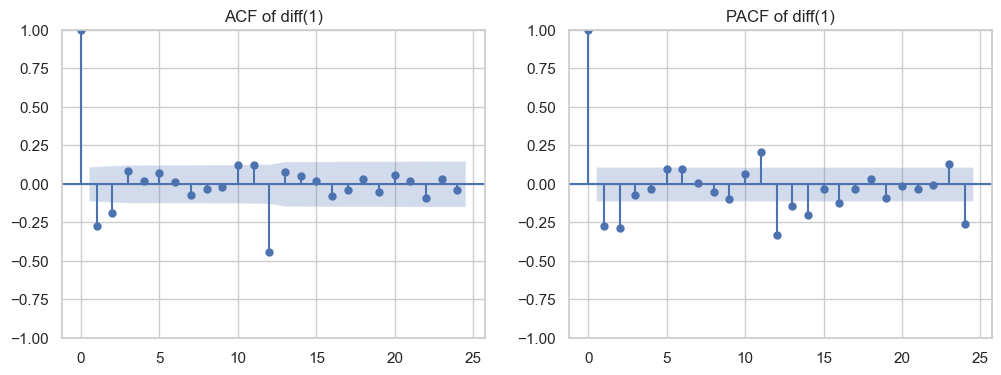

In [132]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(y_seas_diff.dropna(), lags=24, ax=axes[0])
axes[0].set_title("ACF of diff(1)")
plot_pacf(y_seas_diff.dropna(), lags=24, ax=axes[1], method="ywm")
axes[1].set_title("PACF of diff(1)")
plt.show()

#### Interpreting the finished plots

In the above example we see that there is no apparent pattern in the PACF or ACF plots. This is a symptom of white noise, meaning there is no pattern based on the lags on this transformation of the series. This means we will set the parameters of AR and MA components of the ARIMA to 0. The model won't be useless though, the seasonal component of the SARIMA will give us some predictive power. 

## Automating the Process

The project of creating a automatic forecast app will involve engineering robust solutions to each step in the modeling process.
1. Getting and understanding data
2. Diagnosing the process
3. Initial modeling
4. Evaluating candidate model and making improvements
5. Producing forecasts

### 1: Getting and understanding data

For the first step we will need to build a system to import and clean CSVs and Excel files. It is often the case that real world data will have an unspecified frequency, unspecified date format, and other issues like missing or multiple values. Each of these situations is solvable given that they are detected, and the cleaning steps can often be done with simple pandas and numpy usage. Some things however cannot be done without information not contained in the data. The prediction target and exogenous variables need to be explicitely declared by the user, stored, and used when we apply changes to clean the data. The domain/context of the data needs to be understood as well. Each domain, industry, and context entails a slightly different approach and yields slightly different forecasting results. To solve this problem we will create a set of domain/industries that users can categorize their data into. This will give us an idea of what success metrics to aim for.

| Domain / Industry                          | Typical MAPE Range | Best-Achievable (Strong Models & X) | Notes |
|---------------------------------------------|---------------------|--------------------------------------|-------|
| **Electricity Load Forecasting**           | 3–8%               | **1–4%**                             | Strong seasonality; weather X gives huge improvements |
| **Traffic / Pedestrian / Bike Counts**     | 5–12%              | **3–8%**                             | Calendar + weather X = major gains |
| **Retail Sales (with promotions X)**       | 10–20%             | **5–12%**                            | Promotions dominate signal; SARIMAX works great |
| **Retail Sales (no X features)**           | 15–30%             | 12–22%                               | Pure ARIMA struggles in retail without regressors |
| **E-commerce Daily Orders**                | 15–35%             | 10–20%                               | Highly noisy; X reduces volatility |
| **Call Center / Staffing Forecasts**       | 5–15%              | **3–8%**                             | Seasonality-driven with calendar effects |
| **Manufacturing Demand**                   | 10–25%             | 8–15%                                | Lumpy; lagged X helps |
| **Supply Chain / Inventory Forecasting**   | 15–40%             | 12–25%                               | Backorders + variability → SARIMAX helps |
| **Macroeconomic Indicators**               | 10–30%             | 8–20%                                | Relatively stable but slow-moving |
| **Tourism / Hospitality**                  | 10–25%             | 7–15%                                | Strong seasonality; weather + holidays matter |
| **Ad Spend → Conversions**                 | 20–40%             | 10–25%                               | Very noisy; X from campaigns drives improvements |
| **Healthcare Volume (appointments, ED)**   | 15–35%             | 10–20%                               | Noise + policy shifts |
| **Insurance Claims**                        | 20–40%             | 12–28%                               | Depends heavily on exogenous drivers |
| **Weather-driven Industrial Processes**    | 5–15%              | **3–8%**                             | SARIMAX thrives with environmental X |
| **Agriculture / Crop Forecasting**         | 20–50%             | 15–30%                               | Highly exogenous, climate-driven |
| **Financial Time Series (returns)**        | 40–120%            | 25–60%                               | ARIMA weak; volatility dominates |
| **Crypto or Chaotic Series**               | 60–150%            | 40–80%                               | Extremely unpredictable |
| **Short Series (<2 years)**                | 20–50%             | 15–30%                                | X is crucial; seasonality unreliable |
| **New Product Forecasting**                | 30–70%             | 20–50%                                | No history → regressors dominate |


Note that the above chart mentions exogenuous and X often. This is the X part of our SARIMAX model, and essentially means features besides our prediction target that are useful in predicting the target's movement. Exogenous variables help us in predicting breaks from the patterns in the data, and are really the driving factor behind a good forecast. It will often be the case that our users have no exogenous variables contained in their data they submit, so later down the line we will need to use the domain/context to decide what data would be useful in the exogenous component, and then get that data from an API to merge with the user's data. It is EXTREMELY important to note that any exogenous variables we use, whether they be from an API or from submitted data, cannot contain information about the prediction target and cannot be a feature unobtainable before the forecast is produced in practice. 

### 2: Diagnosing the process

It is going to be absolutely indispensable to use OOP for the transforming process. We will need a class, call it "TimeSeriesTransformer", that stores the information of how the series was transformed, differenced, and how to undo those operations. Reminder that our process is: Resample, graph (to gain information about patterns), decomp, **transform**, differencing (seasonal first if present), ACF/PACF, modeling, forecast, **untransform**. In this hypothetical class we need to have an attribute for the **Transformation** (box-cox, yeo-johnson), (lambda for box-cox or yeo-johnson), constant shifts (this will likely not be used in our approach); an attribute for the **Differencing** (seasonal period), (D, seasonal difference), (d, non-seasonal difference), (last original values for d and D to reconstruct forecasts via cumulative sums). It could also be good to have a method for STL decomposition built in but that's not strictly necessary. 

### Other notes:

For now, it is not going to be possible to discuss every step that needs to be taken. There are some problems that are pretty large in scope, like being able to gain information about seasonality and other trends without relying on human intelligence (this will likely just involve some mathematical tests and such). For now we need to ensure that the first step of forecasting is done thoroughly, and that we can handle tons of cases on the most crucial step: data cleaning.  